In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv('Diwali Sales Data.csv', encoding = 'unicode_escape')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Product_ID        11251 non-null  object 
 2   Gender            11251 non-null  object 
 3   Age Group         11251 non-null  object 
 4   Age               11251 non-null  int64  
 5   Marital_Status    11251 non-null  int64  
 6   State             11251 non-null  object 
 7   Zone              11251 non-null  object 
 8   Occupation        11251 non-null  object 
 9   Product_Category  11251 non-null  object 
 10  Orders            11251 non-null  int64  
 11  Amount            11239 non-null  float64
 12  Status            0 non-null      float64
 13  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(7)
memory usage: 1.2+ MB


In [4]:
df.head(5)

,User_ID,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Gift Card,1,23952.0,NaN,NaN
1,1000732,P00110942,F,26-35,35,1,AndhraÃÂ Pradesh,Southern,Govt,Gift Card,3,23934.0,NaN,NaN
2,1001990,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Gift Card,3,23924.0,NaN,NaN
3,1001425,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Gift Card,2,23912.0,NaN,NaN
4,1000588,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Gift Card,2,23877.0,NaN,NaN


# **Data Cleaning**

In [5]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [6]:
df.head(5)

,User_ID,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Gift Card,1,23952.0
1,1000732,P00110942,F,26-35,35,1,AndhraÃÂ Pradesh,Southern,Govt,Gift Card,3,23934.0
2,1001990,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Gift Card,3,23924.0
3,1001425,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Gift Card,2,23912.0
4,1000588,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Gift Card,2,23877.0


In [7]:
df.isnull().sum()

User_ID              0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
# Fix mojibake issues
df['State'] = df['State'].apply(lambda x: x.encode('latin1').decode('utf-8') if isinstance(x, str) else x)
import re

# Remove non-ASCII and extra whitespaces
df['State'] = df['State'].apply(lambda x: re.sub(r'[^\x00-\x7F]+',' ', x).strip() if isinstance(x, str) else x)

# **Exploratory Data Analysis**

In [10]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610858
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [11]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status',
       'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount'],
      dtype='object')

### Gender

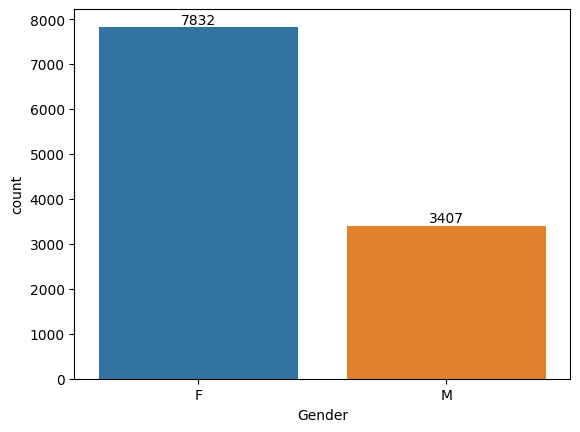

In [12]:
# plotting a bar chart for Gender and it's count

ax = sns.countplot(x = 'Gender',data = df, hue = 'Gender')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

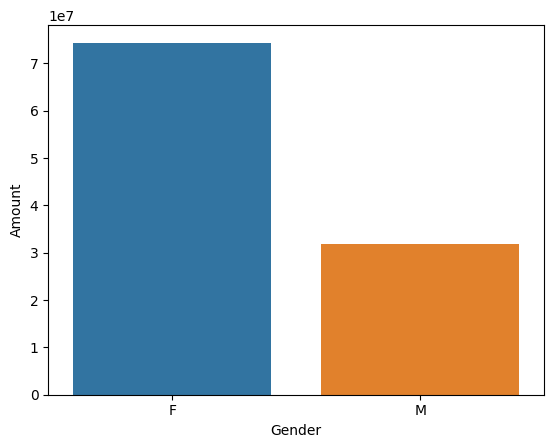

In [13]:
sales_amount = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x = 'Gender',y= 'Amount' ,data = sales_amount, hue = 'Gender')

*From above graphs we can see that most of the buyers are females and indicates that female customers are the key revenue drivers for the business.*

### Age

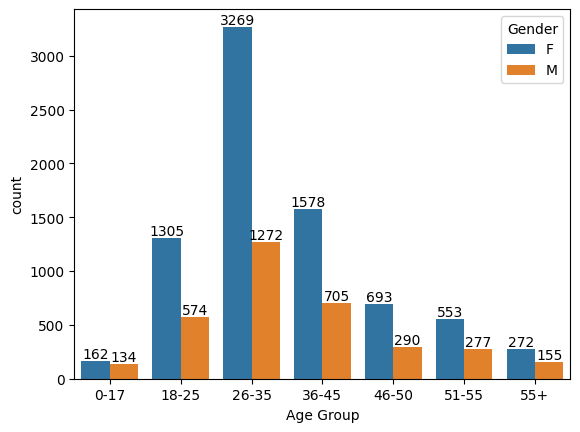

In [14]:
sorted_age = df['Age Group'].sort_values(ascending=True)
ax = sns.countplot(data = df, x = 'Age Group', hue = 'Gender', order=sorted_age)

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

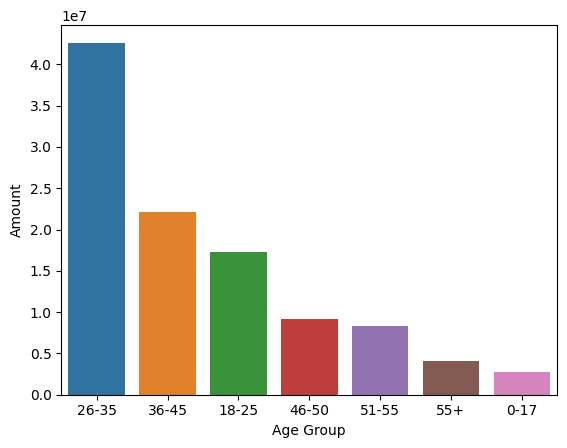

In [15]:
# how much each age group spends
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Age Group',y= 'Amount' ,data = sales_age, hue='Age Group')

*From the above graphs, it is evident that the majority of buyers belong to the 26–35 age group, with females being the most prominent contributors within this segment.*|

### States

<Axes: xlabel='State', ylabel='Orders'>

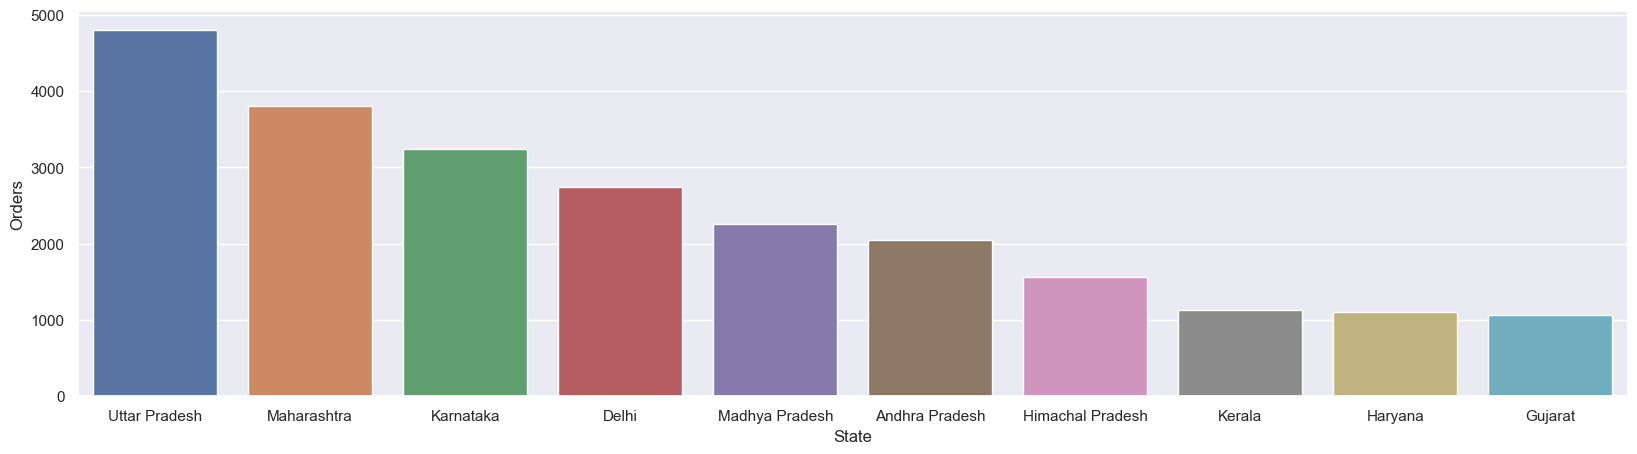

In [16]:
# total number of orders from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Orders', hue ='State')

<Axes: xlabel='State', ylabel='Amount'>

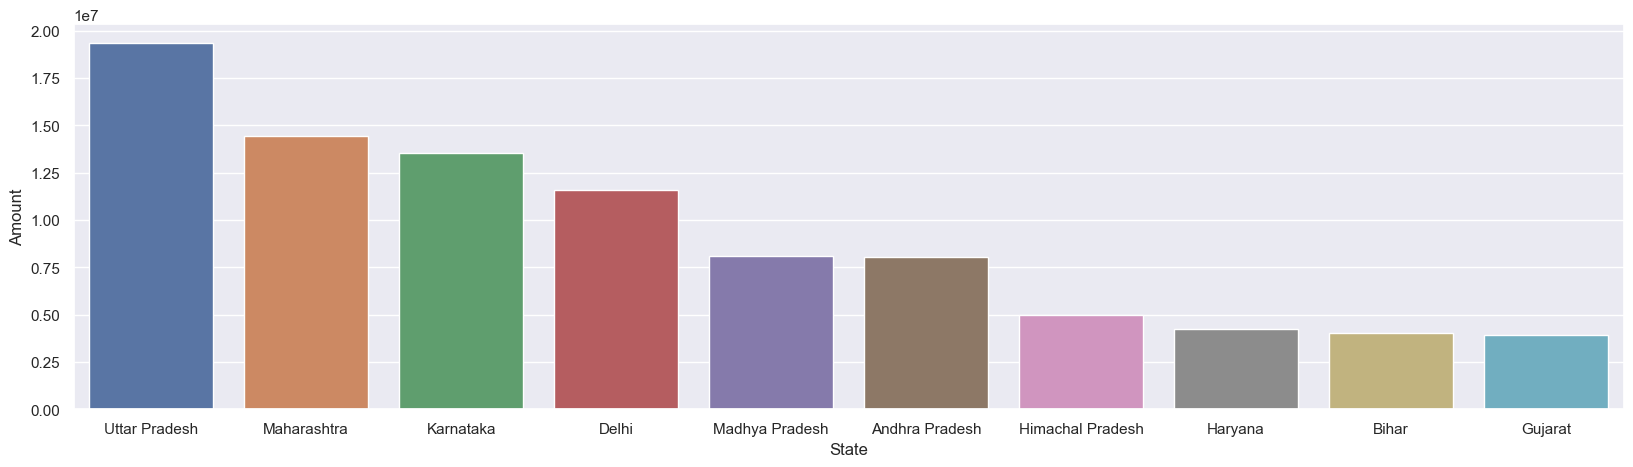

In [17]:
# total amount/sales from top 10 states
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Amount', hue='State')

*From the above graphs, it is evident that most of the buyers are from Uttar Pradesh, Maharashtra and Karnataka*

### Marital Status

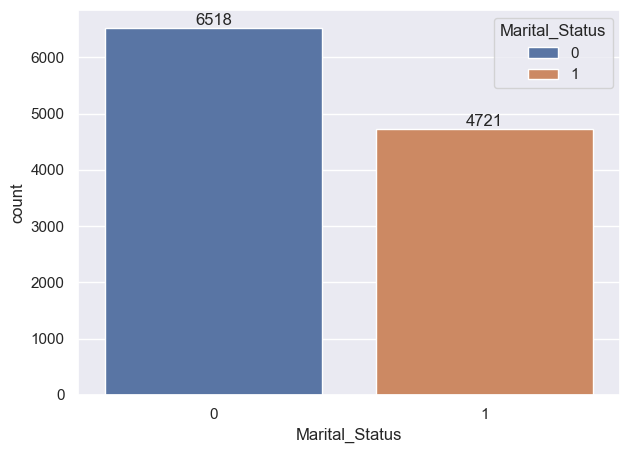

In [18]:
sns.set(rc={'figure.figsize':(7,5)})
# Map the values

ax = sns.countplot(data = df, x = 'Marital_Status', hue = 'Marital_Status')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

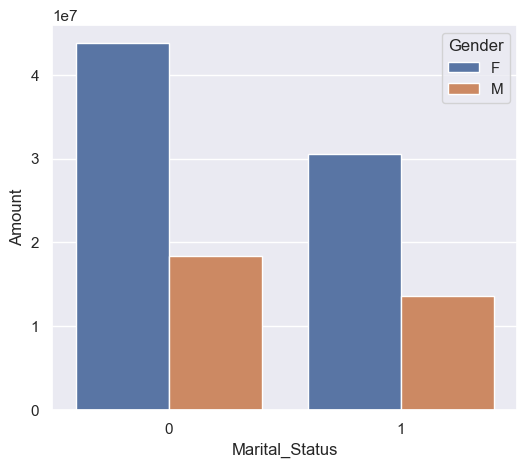

In [19]:
sns.set(rc={'figure.figsize':(6,5)})
# Map the values

sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(data = sales_state, x = 'Marital_Status', y= 'Amount', hue='Gender')

### Occupation

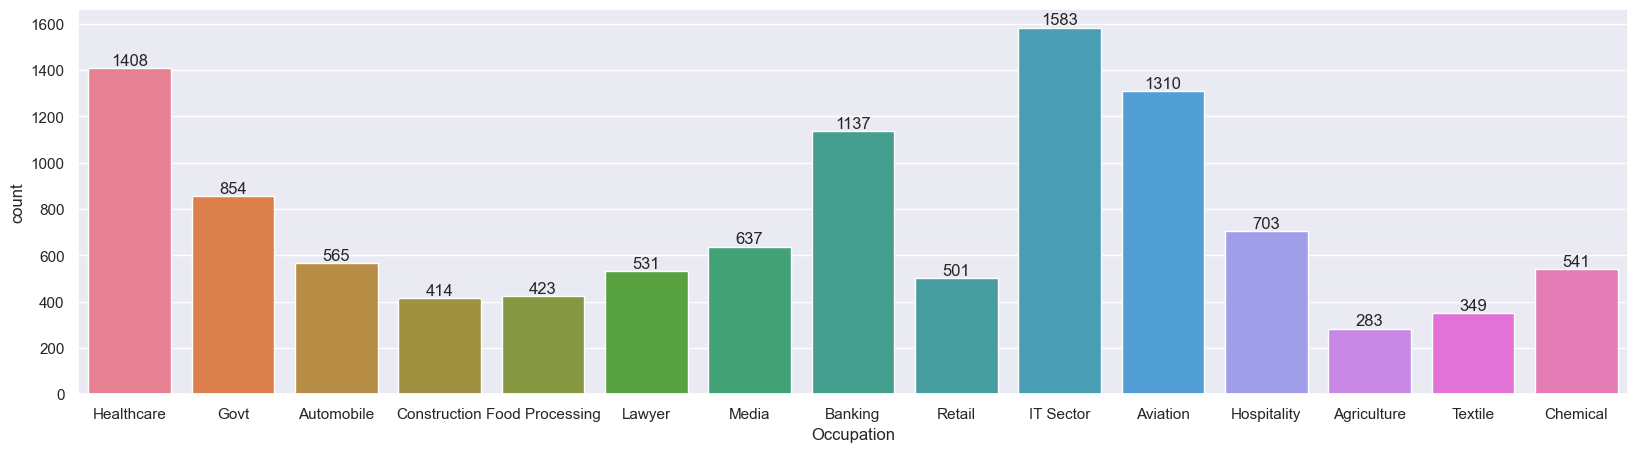

In [20]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation', hue = 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

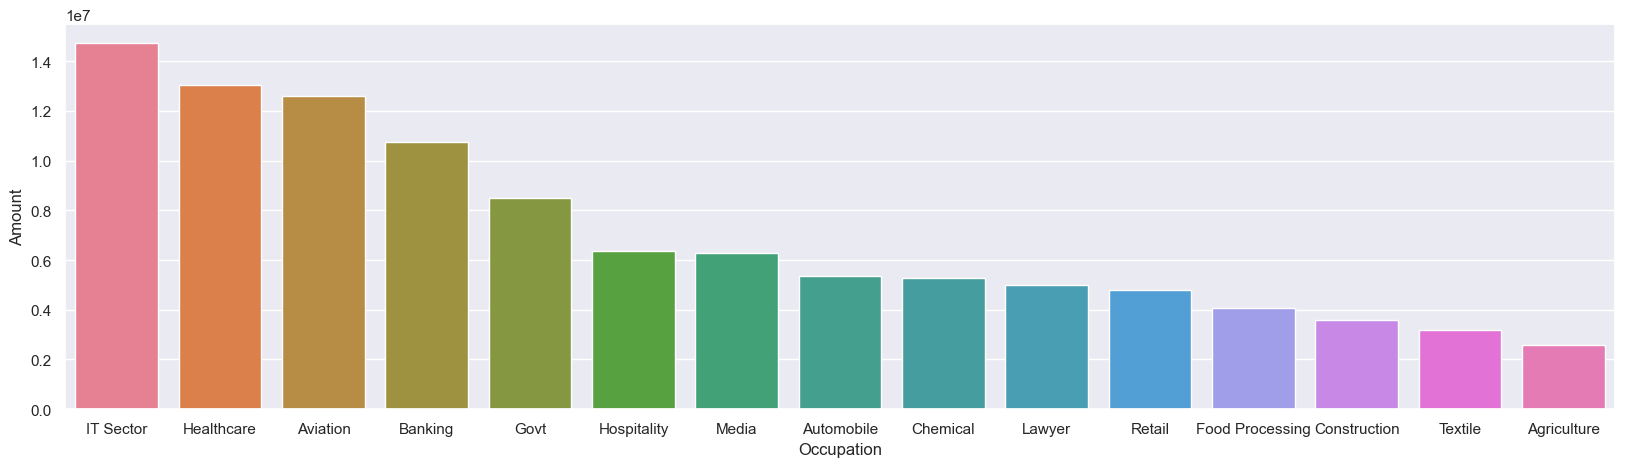

In [21]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount', hue = 'Occupation')

*From the above graphs, it is evident that most of the buyers are from the IT sector, health care and aviation*

### Product Category

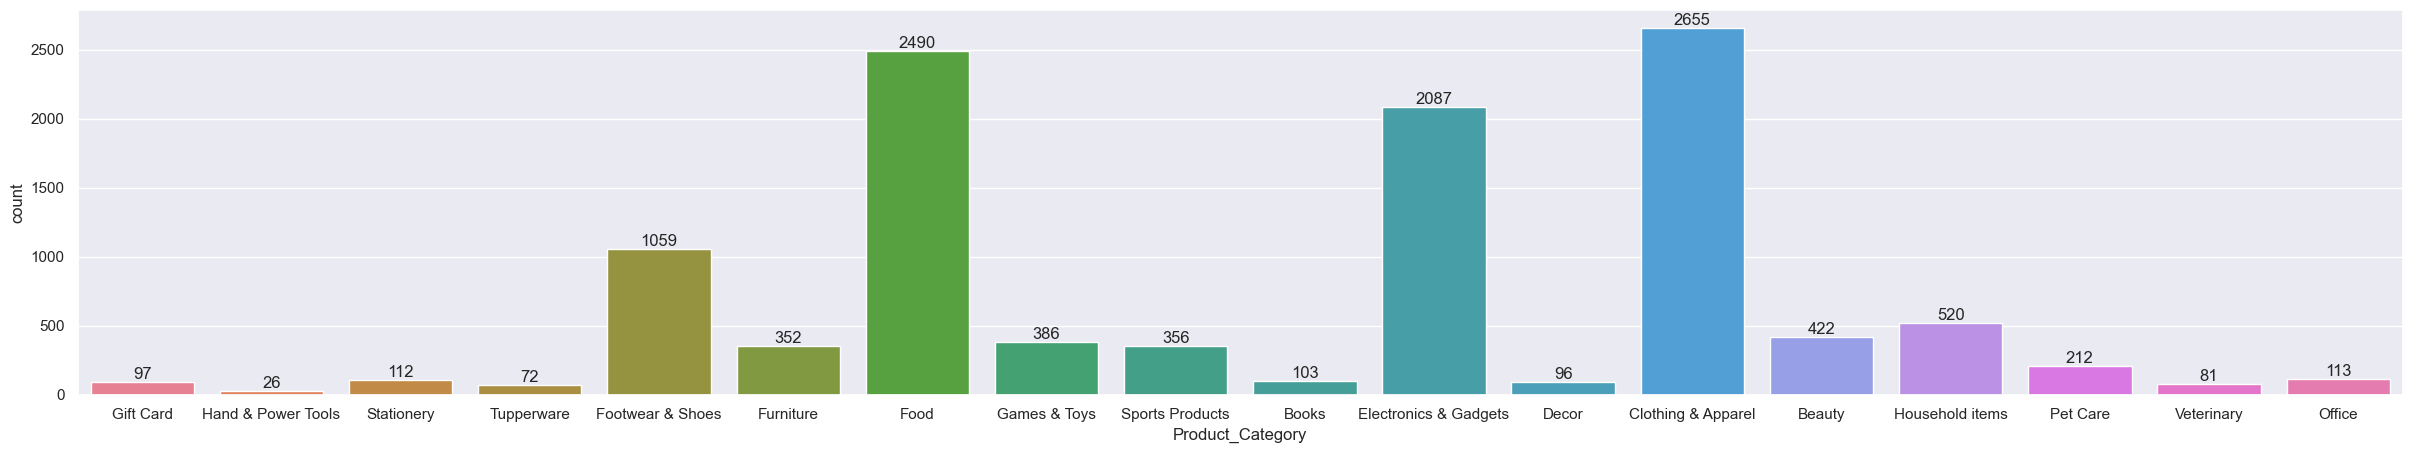

In [22]:
sns.set(rc={'figure.figsize':(30,5)})
ax = sns.countplot(data = df, x = 'Product_Category', hue = 'Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

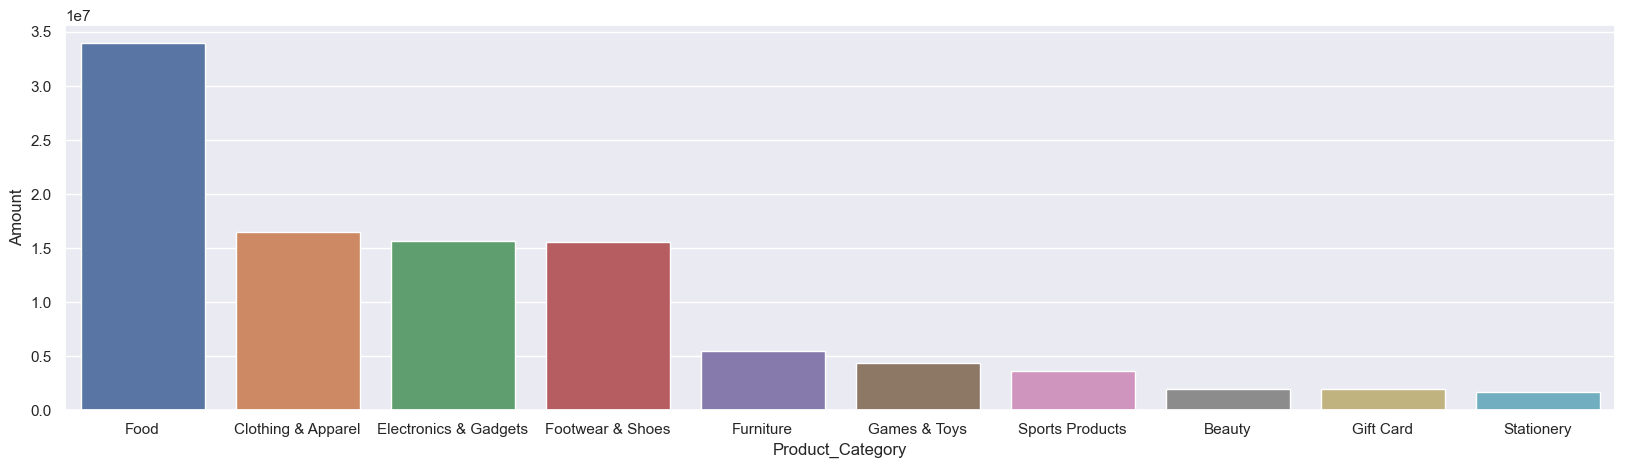

In [23]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount', hue = 'Product_Category')

*From the above graphs, it is evident that most the products sold are from Food, Clothing & Apparel and Electronics and Gadgets*

### Product ID and Orders

<Axes: xlabel='Product_ID', ylabel='Orders'>

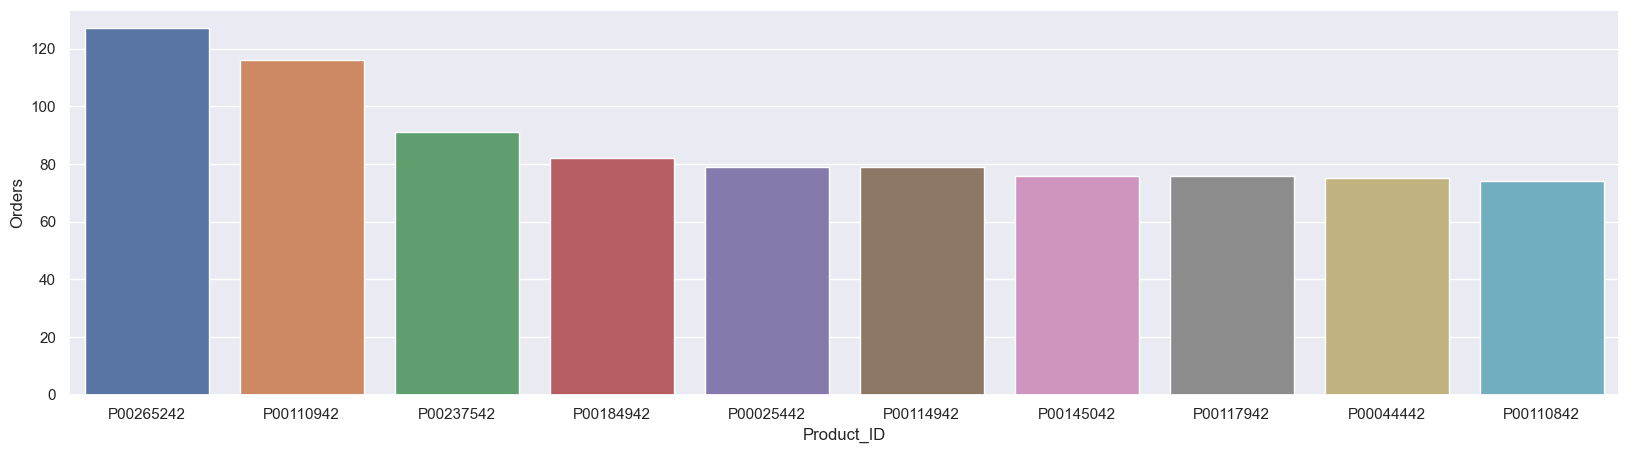

In [24]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders', hue = 'Product_ID')

*The barplot reveals the top 10 most sold products based on order count. Product P00265242 is the highest selling item, followed by P00110942 and P00237542.*

## **Conclusion**

##### *Married women aged 26–35 from Uttar Pradesh, Maharashtra, and Karnataka, working in IT, Healthcare, and Aviation sectors, show a higher tendency to purchase products from the Food, Clothing, and Electronics categories.*